# Wetterich equation ϕ4 flow in d = 3

In [43]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import h5py

### Litim Regulator

/tmp/ipykernel_26910/1264617393.py:5: RuntimeWarning: divide by zero encountered in scalar divide
  return y*(1/y-1)
/tmp/ipykernel_26910/1264617393.py:5: RuntimeWarning: invalid value encountered in scalar multiply
  return y*(1/y-1)


Text(0, 0.5, 'R_k/K²')

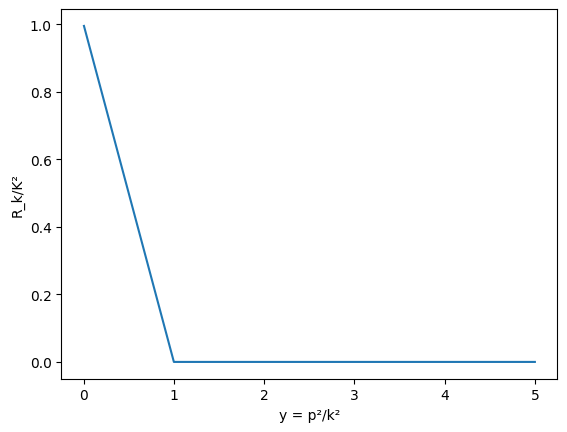

In [44]:
def litim(y):
    if 1 < y:
        return 0
    else:
        return y*(1/y-1)
    
y = np.linspace(0,5,1000)
R_vals = np.zeros(1000)

for i in range(len(y)):
    R_vals[i] = litim(y[i])

plt.plot(y, R_vals)
plt.xlabel("y = p²/k²")
plt.ylabel("R_k/K²")

## Classical ϕ4 potential and derivatives

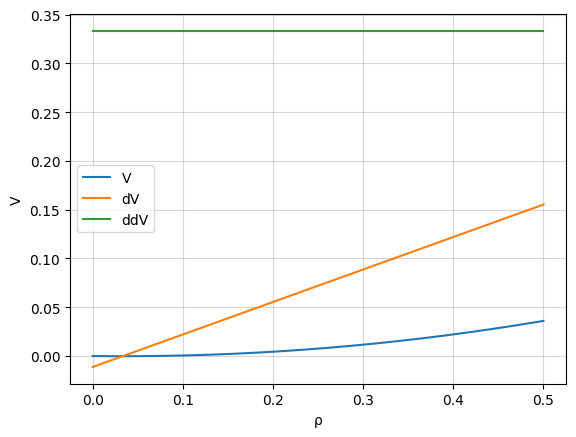

In [45]:
data = np.loadtxt("../results/V_classical.txt", skiprows=1, delimiter=",")
data_1 = np.loadtxt("../results/V_classical_prime.txt", skiprows=1, delimiter=",")
data_2 = np.loadtxt("../results/V_classical_doubleprime.txt", skiprows=1, delimiter=",")

ρ = data[:,0]
V = data[:,1]

ρ2 = data_1[:,0]
dV = data_1[:,1]

ρ3 = data_2[:,0]
ddV = data_2[:,1]

plt.plot(ρ,V,label="V")
plt.xlabel("ρ")
plt.ylabel("V")
plt.plot(ρ2,dV, label="dV")
plt.plot(ρ3,ddV, label="ddV")
plt.legend()
plt.grid(alpha=0.5)
plt.show()

### initial RHS of Flow equation

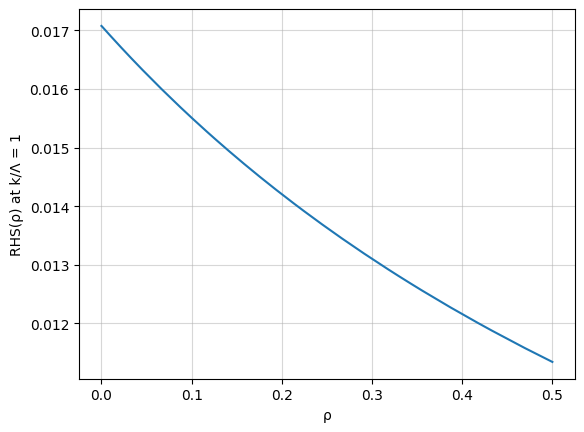

In [46]:
RHS = np.loadtxt("../results/RHS.txt", skiprows=1, delimiter=",")

ρ = RHS[:,0]
RHS = RHS[:,1]

plt.plot(ρ,RHS)
plt.xlabel("ρ")
# plt.xscale("log")
# plt.yscale("log")
plt.ylabel("RHS(ρ) at k/Λ = 1")
plt.grid(alpha=0.5)

## Flow equation solution

Read fron CSV file

In [47]:
from pathlib import Path
CSV_PATH = Path("../results/flow.csv")

# Read metadata from comment lines
meta = {}
with open(CSV_PATH) as f:
    for line in f:
        if not line.startswith("#"):
            break
        # lines look like:  # key=val  key=val ...
        for token in line.lstrip("# ").split():
            if "=" in token:
                k, v = token.split("=", 1)
                meta[k.strip()] = v.strip()

print("Metadata:", meta)

# Read the data; comment char skips the # lines automatically
df = pd.read_csv(CSV_PATH, comment="#")

# First column is rho, remaining columns are k=... snapshots
rho_grid = df.iloc[:, 0].to_numpy()
k_values = np.array([float(col.split("=")[1]) for col in df.columns[1:]])
t_values = np.log(k_values)          # t = ln(k), negative in IR
V_grid   = df.iloc[:, 1:].to_numpy().T   # shape: (n_snapshots, n_rho)

print(f"rho: {rho_grid[0]:.4f} .. {rho_grid[-1]:.4f}  ({len(rho_grid)} points)")
print(f"k values: {k_values}")
print(f"V_grid shape: {V_grid.shape}")

Metadata: {'d': '3', '': ''}
rho: 0.0000 .. 0.5000  (1000 points)
k values: [1.       0.950754 0.903933 0.859418 0.817095 0.776856 0.738599 0.702226
 0.667644 0.634765 0.603445 0.573728 0.545474 0.518612 0.493072 0.46879
 0.445704 0.423755 0.402887 0.383046 0.364183 0.346248 0.329197 0.312985
 0.297572 0.282917 0.268985 0.255738 0.243144 0.23117  0.219764 0.208942
 0.198652 0.188869 0.179568 0.170725 0.162318 0.154324 0.146724 0.139499
 0.132629 0.126097 0.119888 0.113984 0.10837  0.103034 0.09796  0.093135
 0.088549 0.084188 0.080034 0.076093 0.072346 0.068783 0.065396 0.062175
 0.059113 0.056202 0.053434 0.050803 0.048301 0.045923 0.043661 0.041511
 0.039467 0.037523 0.035675 0.033918 0.032248 0.03066  0.029147 0.027712
 0.026347 0.02505  0.023816 0.022643 0.021528 0.020468 0.01946  0.018502
 0.01759  0.016724 0.015901 0.015118 0.014373 0.013665 0.012992 0.012352
 0.011744 0.011166 0.010615 0.010092 0.009595 0.009123 0.008673 0.008246
 0.00784  0.007454 0.007087 0.006738]
V_grid shap

## Flow of the effective potential

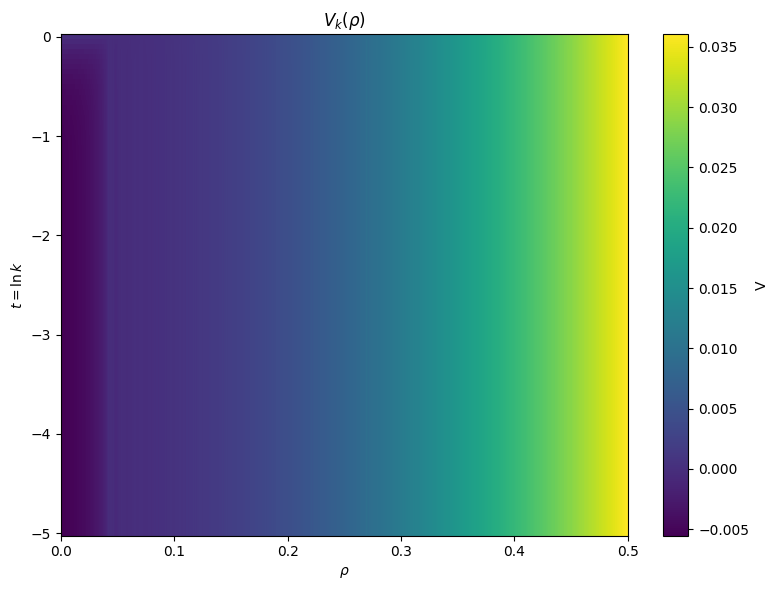

In [48]:
fig, ax = plt.subplots(figsize=(8, 6))
mesh = ax.pcolormesh(rho_grid, t_values, V_grid, shading="auto", cmap="viridis")
ax.set_xlabel(r"$\rho$")
ax.set_ylabel(r"$t = \ln k$")
ax.set_title(r"$V_k(\rho)$")
fig.colorbar(mesh, ax=ax, label="V")
plt.tight_layout()
plt.show()

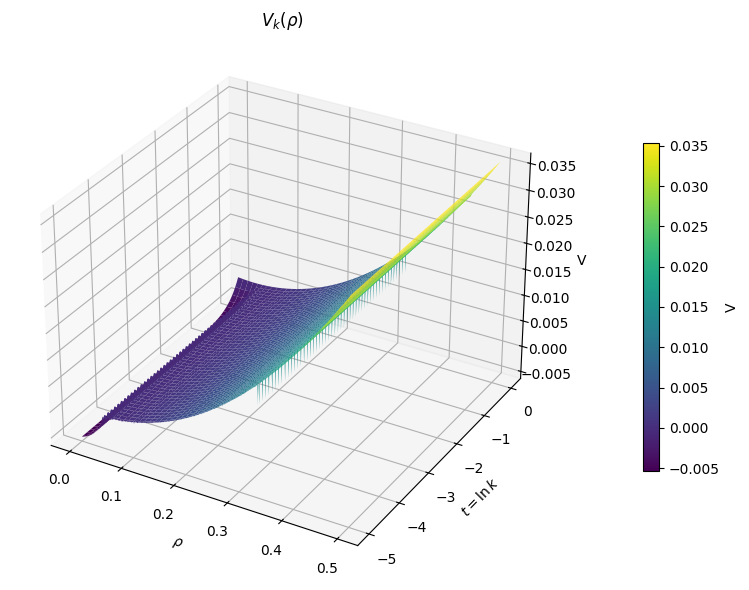

In [49]:
Rho, T = np.meshgrid(rho_grid, t_values)

fig = plt.figure(figsize=(9, 6))
ax  = fig.add_subplot(111, projection="3d")
surf = ax.plot_surface(Rho, T, V_grid, cmap="viridis", edgecolor="none")
ax.set_xlabel(r"$\rho$")
ax.set_ylabel(r"$t = \ln k$")
ax.set_zlabel("V")
ax.set_title(r"$V_k(\rho)$")
fig.colorbar(surf, ax=ax, shrink=0.6, pad=0.1, label="V")
plt.tight_layout()
plt.show()

## Flow of the effective potential relative to the initial condition

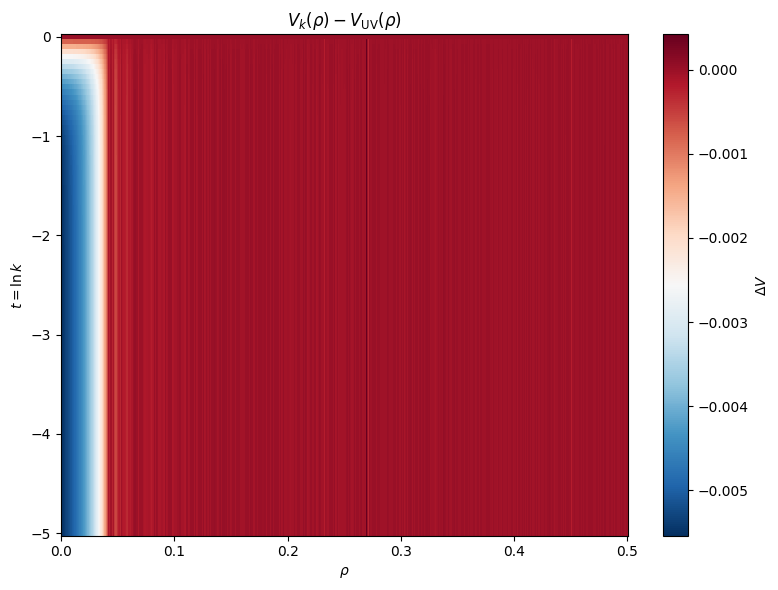

In [50]:
V_ref  = V_grid[0]          # UV snapshot  (largest k)
V_diff = V_grid - V_ref

fig, ax = plt.subplots(figsize=(8, 6))
mesh = ax.pcolormesh(rho_grid, t_values, V_diff, shading="auto", cmap="RdBu_r")
ax.set_xlabel(r"$\rho$")
ax.set_ylabel(r"$t = \ln k$")
ax.set_title(r"$V_k(\rho) - V_{\mathrm{UV}}(\rho)$")
fig.colorbar(mesh, ax=ax, label=r"$\Delta V$")
plt.tight_layout()
plt.show()

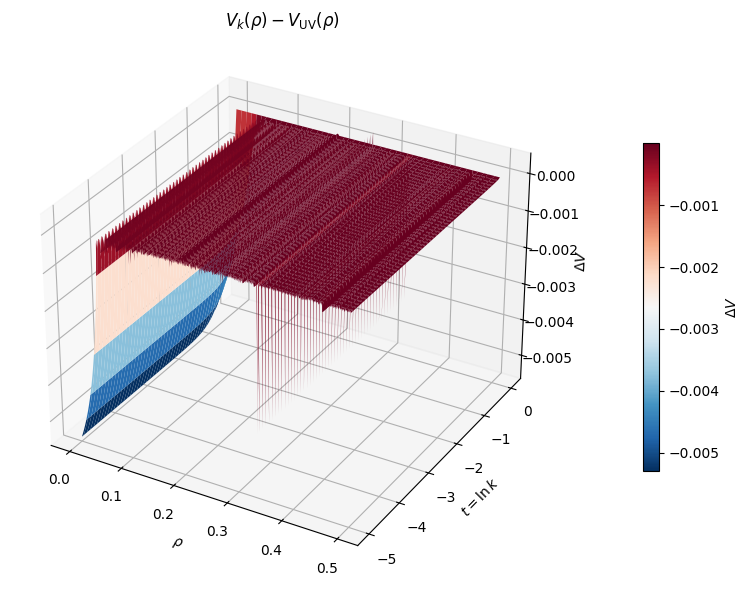

In [54]:
Rho, T = np.meshgrid(rho_grid, t_values)

fig = plt.figure(figsize=(9, 6))
ax  = fig.add_subplot(111, projection="3d")
surf = ax.plot_surface(Rho, T, V_diff, cmap="RdBu_r", edgecolor="none")
ax.set_xlabel(r"$\rho$")
ax.set_ylabel(r"$t = \ln k$")
ax.set_zlabel(r"$\Delta V$")
ax.set_title(r"$V_k(\rho) - V_{\mathrm{UV}}(\rho)$")
fig.colorbar(surf, ax=ax, shrink=0.6, pad=0.1, label=r"$\Delta V$")
plt.tight_layout()
plt.show()

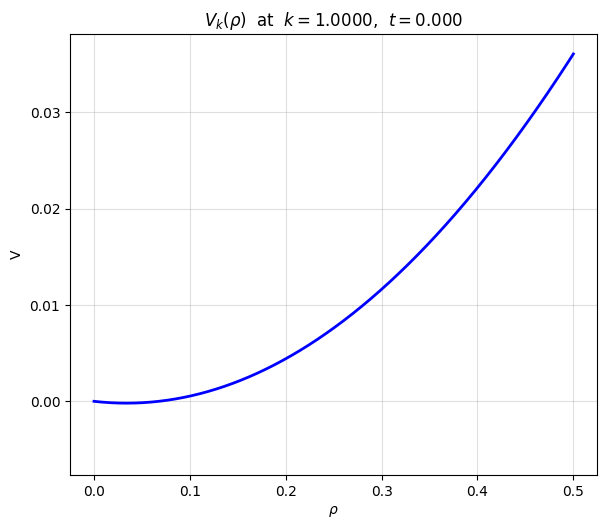

In [51]:
fig, ax = plt.subplots(figsize=(6, 5))

# Fix y-limits across all frames
y_min, y_max = V_grid.min(), V_grid.max()
margin = 0.05 * (y_max - y_min)

def animate(frame):
    ax.clear()
    ax.plot(rho_grid, V_grid[frame], "b-", linewidth=2)
    ax.set_xlabel(r"$\rho$")
    ax.set_ylabel("V")
    ax.set_title(rf"$V_k(\rho)$  at  $k = {k_values[frame]:.4f}$,  $t = {t_values[frame]:.3f}$")
    ax.set_ylim(y_min - margin, y_max + margin)
    ax.grid(alpha=0.4)

anim = FuncAnimation(fig, animate, frames=len(t_values), interval=120, repeat=True)
plt.tight_layout()
HTML(anim.to_jshtml())

## Flowing minimum of potential

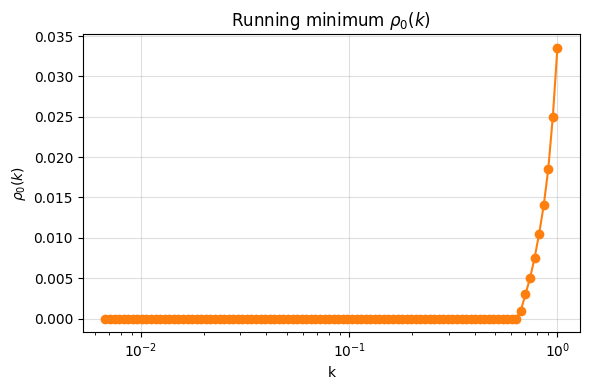

In [52]:
# Find the rho at which V is minimised for each snapshot
rho0 = rho_grid[np.argmin(V_grid, axis=1)]

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(k_values, rho0, "o-", color="tab:orange")
ax.set_xlabel("k")
ax.set_ylabel(r"$\rho_0(k)$")
ax.set_title(r"Running minimum $\rho_0(k)$")
ax.set_xscale("log")
ax.grid(alpha=0.4)
plt.tight_layout()
plt.show()